In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
data = pd.read_csv("clustering.csv")

In [5]:
data.shape

(381, 13)

In [6]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


In [7]:
data.isna().sum()

Loan_ID               0
Gender                5
Married               0
Dependents            8
Education             0
Self_Employed        21
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     11
Credit_History       30
Property_Area         0
Loan_Status           0
dtype: int64

In [9]:
data.dropna(inplace=True)
data.shape

(308, 13)

Text(0, 0.5, 'Loan Amount (In Thousands)')

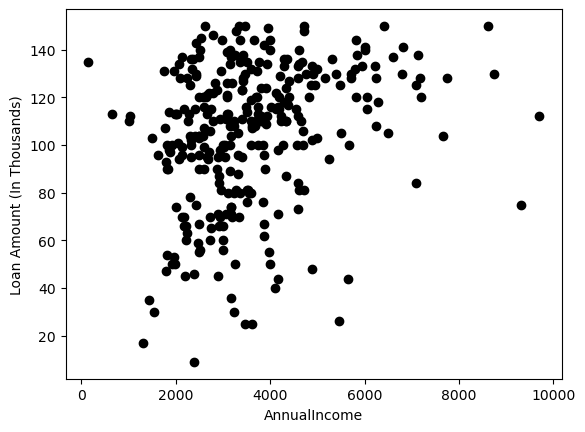

In [13]:
#For this article, we will be taking only two variables from the data 
# – “LoanAmount” and “ApplicantIncome.” 

# This will make it easy to visualize the steps as well. 
# Let’s pick these two variables and visualize the data points:


X = data[["LoanAmount","ApplicantIncome"]]

#Visualise data points
plt.scatter(X["ApplicantIncome"],X["LoanAmount"],c='black')
plt.xlabel('AnnualIncome')
plt.ylabel('Loan Amount (In Thousands)')


In [14]:
data.drop('Loan_ID', axis=1, inplace =True)

In [16]:
data.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [17]:
data.Gender.unique()

array(['Male', 'Female'], dtype=object)

In [18]:
data.Married.unique()

array(['Yes', 'No'], dtype=object)

In [19]:
data.Dependents.unique()

array(['1', '0', '2', '3+'], dtype=object)

In [27]:
data.Dependents = data.Dependents.apply(lambda x: 1 if x=="1" else 2 if x=="2" else 0 if x=="0" else 3)

In [20]:
data.Education.unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [21]:
data.Self_Employed.unique()

array(['No', 'Yes'], dtype=object)

In [22]:
data.Loan_Amount_Term.unique()

array([360., 120., 180.,  60., 300., 480., 240.,  84.,  36.])

In [23]:
data.Credit_History.unique()

array([1., 0.])

In [24]:
data.Property_Area.unique()

array(['Rural', 'Urban', 'Semiurban'], dtype=object)

In [25]:
data.Loan_Status.unique()

array(['N', 'Y'], dtype=object)

In [30]:
encoded_data = pd.get_dummies(data, dtype=int)

In [31]:
encoded_data

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Female,Gender_Male,Married_No,Married_Yes,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_N,Loan_Status_Y
0,1,4583,1508.0,128.0,360.0,1.0,0,1,0,1,1,0,1,0,1,0,0,1,0
1,0,3000,0.0,66.0,360.0,1.0,0,1,0,1,1,0,0,1,0,0,1,0,1
2,0,2583,2358.0,120.0,360.0,1.0,0,1,0,1,0,1,1,0,0,0,1,0,1
3,0,6000,0.0,141.0,360.0,1.0,0,1,1,0,1,0,1,0,0,0,1,0,1
4,0,2333,1516.0,95.0,360.0,1.0,0,1,0,1,0,1,1,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
376,3,5703,0.0,128.0,360.0,1.0,0,1,0,1,1,0,1,0,0,0,1,0,1
377,0,3232,1950.0,108.0,360.0,1.0,0,1,0,1,1,0,1,0,1,0,0,0,1
378,0,2900,0.0,71.0,360.0,1.0,1,0,1,0,1,0,1,0,1,0,0,0,1
379,3,4106,0.0,40.0,180.0,1.0,0,1,0,1,1,0,1,0,1,0,0,0,1


In [32]:
import warnings
warnings.filterwarnings('ignore')

In [34]:
from sklearn.cluster import KMeans

In [35]:
kmeans = KMeans(n_clusters=2)

In [36]:
kmeans.fit(encoded_data)

KMeans(n_clusters=2)

In [37]:
kmeans.inertia_

1976440194.8526168

Text(0, 0.5, 'Inertia')

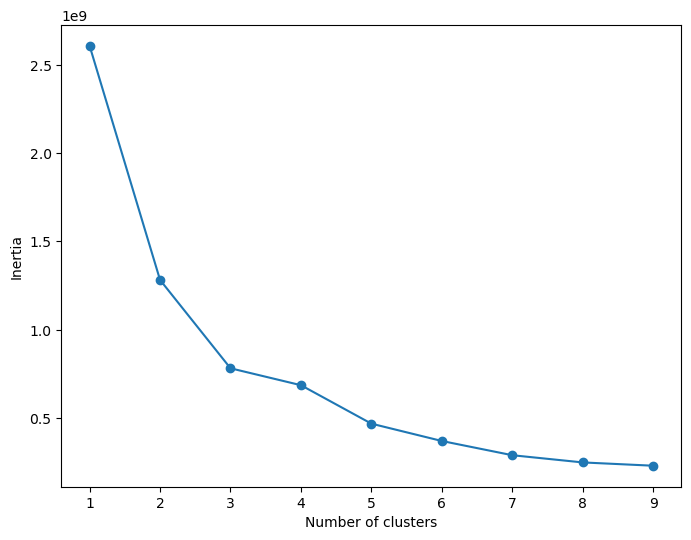

In [40]:
# fitting multiple k-means algorithms and storing the values in an empty list
# within cluster sum of sqaure
wcss = []
for cluster in range(1,10):
    kmeans = KMeans(n_clusters = cluster, init='k-means++')
    kmeans.fit(encoded_data)
    wcss.append(kmeans.inertia_)

# converting the results into a dataframe and plotting them
frame = pd.DataFrame({'Cluster':range(1,10), 'wcss':wcss})

plt.figure(figsize=(8,6))

plt.plot(frame['Cluster'], frame['wcss'], marker='o')

plt.xlabel('Number of clusters')

plt.ylabel('Inertia')


In [42]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(encoded_data)

KMeans(n_clusters=3)

In [43]:
clusters = kmeans.predict(encoded_data)

In [44]:
clusters

array([2, 2, 0, 2, 0, 0, 0, 0, 2, 2, 2, 2, 0, 0, 2, 0, 2, 2, 0, 0, 0, 2,
       0, 0, 2, 2, 0, 0, 0, 2, 2, 2, 0, 0, 0, 0, 0, 2, 2, 0, 2, 2, 0, 2,
       2, 0, 2, 2, 0, 0, 0, 0, 2, 2, 0, 0, 2, 0, 0, 0, 0, 2, 2, 0, 2, 0,
       2, 2, 2, 2, 0, 2, 0, 0, 0, 2, 2, 0, 2, 0, 0, 2, 2, 0, 0, 2, 2, 0,
       0, 2, 0, 2, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 0, 0, 2, 0, 2, 0, 2, 0,
       0, 0, 0, 0, 2, 0, 0, 2, 2, 0, 0, 2, 0, 0, 2, 2, 0, 0, 2, 0, 2, 2,
       0, 2, 2, 2, 0, 2, 0, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 2, 0, 2,
       0, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 2, 2, 0, 0, 0, 2, 2, 0, 2,
       0, 0, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 0, 0, 2, 0,
       0, 2, 0, 0, 0, 2, 2, 1, 0, 2, 0, 0, 2, 0, 2, 0, 0, 2, 0, 0, 2, 2,
       2, 2, 2, 2, 0, 2, 0, 2, 2, 0, 2, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2,
       0, 0, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0,
       2, 0, 0, 2, 2, 0, 2, 2, 2, 2, 0, 0, 0, 0, 2, 0, 2, 0, 0, 2, 2, 2,
       2, 0, 0, 0, 2, 2, 0, 0, 1, 2, 0, 0, 0, 2, 0,

In [45]:
encoded_data['cluster#'] = clusters

In [46]:
encoded_data

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Female,Gender_Male,Married_No,Married_Yes,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_N,Loan_Status_Y,cluster#
0,1,4583,1508.0,128.0,360.0,1.0,0,1,0,1,1,0,1,0,1,0,0,1,0,2
1,0,3000,0.0,66.0,360.0,1.0,0,1,0,1,1,0,0,1,0,0,1,0,1,2
2,0,2583,2358.0,120.0,360.0,1.0,0,1,0,1,0,1,1,0,0,0,1,0,1,0
3,0,6000,0.0,141.0,360.0,1.0,0,1,1,0,1,0,1,0,0,0,1,0,1,2
4,0,2333,1516.0,95.0,360.0,1.0,0,1,0,1,0,1,1,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
376,3,5703,0.0,128.0,360.0,1.0,0,1,0,1,1,0,1,0,0,0,1,0,1,2
377,0,3232,1950.0,108.0,360.0,1.0,0,1,0,1,1,0,1,0,1,0,0,0,1,0
378,0,2900,0.0,71.0,360.0,1.0,1,0,1,0,1,0,1,0,1,0,0,0,1,2
379,3,4106,0.0,40.0,180.0,1.0,0,1,0,1,1,0,1,0,1,0,0,0,1,2


In [47]:
groups = encoded_data.groupby('cluster#')

In [49]:
cluster_0 = groups.get_group(0)
cluster_1 = groups.get_group(1)
cluster_2 = groups.get_group(2)

In [53]:
encoded_data[encoded_data['cluster#'] == 0]


,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Female,Gender_Male,Married_No,Married_Yes,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_N,Loan_Status_Y,cluster#
0,1,4583,1508.0,128.0,360.0,1.0,0,1,0,1,1,0,1,0,1,0,0,1,0,2
1,0,3000,0.0,66.0,360.0,1.0,0,1,0,1,1,0,0,1,0,0,1,0,1,2
3,0,6000,0.0,141.0,360.0,1.0,0,1,1,0,1,0,1,0,0,0,1,0,1,2
9,0,4950,0.0,125.0,360.0,1.0,0,1,1,0,1,0,1,0,0,0,1,0,1,2
11,0,3510,0.0,76.0,360.0,0.0,1,0,1,0,1,0,1,0,0,0,1,1,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374,0,3833,0.0,110.0,360.0,1.0,0,1,1,0,0,1,1,0,1,0,0,0,1,2
376,3,5703,0.0,128.0,360.0,1.0,0,1,0,1,1,0,1,0,0,0,1,0,1,2
378,0,2900,0.0,71.0,360.0,1.0,1,0,1,0,1,0,1,0,1,0,0,0,1,2
379,3,4106,0.0,40.0,180.0,1.0,0,1,0,1,1,0,1,0,1,0,0,0,1,2


(array([ 2.,  7., 12., 13., 25., 25., 55., 70., 60., 39.]),
 array([  9. ,  23.1,  37.2,  51.3,  65.4,  79.5,  93.6, 107.7, 121.8,
        135.9, 150. ]),
 <BarContainer object of 10 artists>)

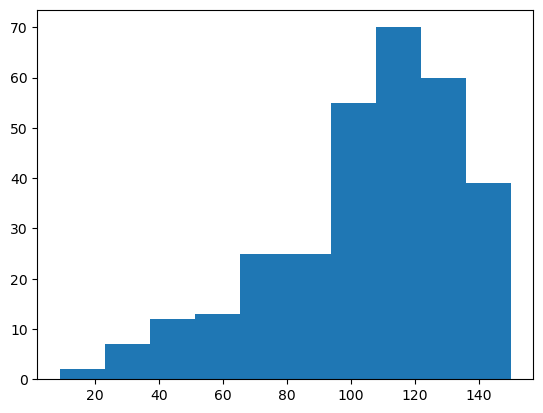

In [58]:
plt.hist(encoded_data.LoanAmount)

In [54]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

In [55]:
# Load the data from the excel file and look at column names
knowledge = pd.read_csv('User Knowledge.csv')
knowledge.head()

,STG,SCG,STR,LPR,PEG
0,0.00,0.00,0.00,0.00,0.00
1,0.08,0.08,0.10,0.24,0.90
2,0.06,0.06,0.05,0.25,0.33
3,0.10,0.10,0.15,0.65,0.30
4,0.08,0.08,0.08,0.98,0.24


In [57]:
knowledge.shape

(403, 5)